# Q6. Interpreting Bayesian linear regression + coding.
Implement Python code that reproduces the three-column, four-row figure for Bayesian linear regression with Gaussian prior and noise. Use the parameters specified above.

N    w0      w1
----------------------
0      0.00    0.00
1     -0.44   -0.04
2     -0.35    0.66
100   -0.26    0.49


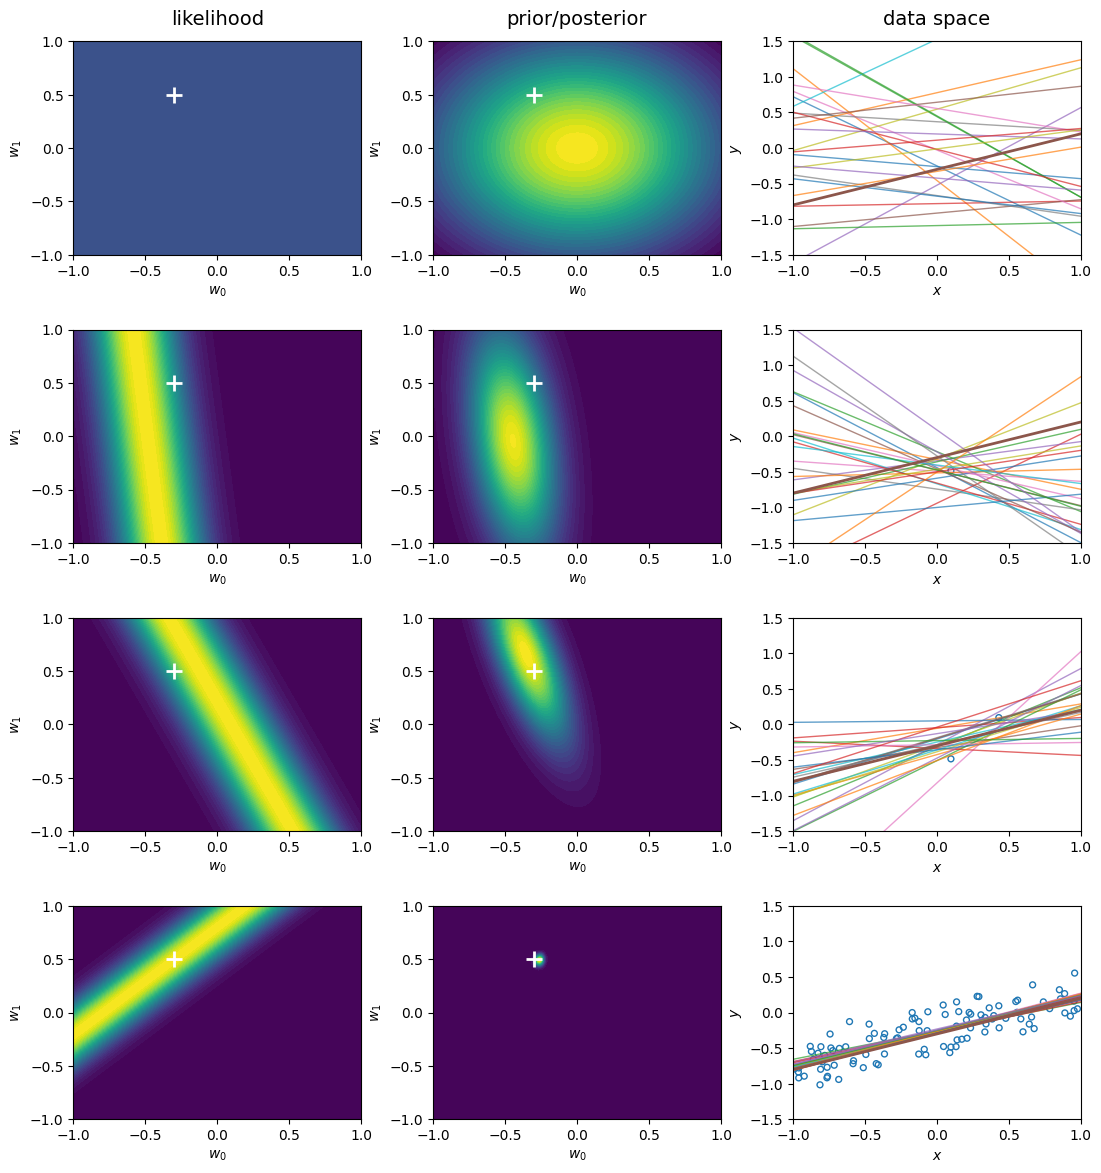

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf_1d(y, mean, var):
    return (1.0 / np.sqrt(2.0 * np.pi * var)) * np.exp(-0.5 * (y - mean) ** 2 / var)

def gaussian_pdf_2d_grid(W0, W1, mu, Sigma):
    invS = np.linalg.inv(Sigma)
    detS = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(detS))

    d0 = W0 - mu[0]
    d1 = W1 - mu[1]
    q = invS[0, 0] * d0**2 + 2.0 * invS[0, 1] * d0 * d1 + invS[1, 1] * d1**2
    return norm * np.exp(-0.5 * q)

def posterior_params(Phi, y, alpha, beta):
    D = Phi.shape[1]
    S_inv = alpha * np.eye(D) + beta * (Phi.T @ Phi)
    Sigma = np.linalg.inv(S_inv)
    mu = beta * (Sigma @ Phi.T @ y)
    return mu, Sigma

# Parameters
np.random.seed(0)
a0_true = -0.3
a1_true = 0.5
sigma = 0.2
sigma2 = sigma**2
beta = 1.0 / sigma2
alpha = 2.0
N_total = 100
stages = [0, 1, 2, 100]

# Generate synthetic data
x_all = np.random.uniform(-1.0, 1.0, size=N_total)
eps = np.random.normal(0.0, sigma, size=N_total)
y_all = a0_true + a1_true * x_all + eps
Phi_all = np.column_stack([np.ones(N_total), x_all])

# Grid for contour plots
grid_min, grid_max = -1.0, 1.0
grid_size = 220
w0 = np.linspace(grid_min, grid_max, grid_size)
w1 = np.linspace(grid_min, grid_max, grid_size)
W0, W1 = np.meshgrid(w0, w1)

# Plot
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

x_plot = np.linspace(-1.0, 1.0, 200)

print("N    w0      w1")
print("-" * 22)

for r, N in enumerate(stages):
    # Posterior
    if N == 0:
        mu_N = np.zeros(2)
        Sigma_N = (1.0 / alpha) * np.eye(2)
    else:
        Phi_N = Phi_all[:N, :]
        y_N = y_all[:N]
        mu_N, Sigma_N = posterior_params(Phi_N, y_N, alpha=alpha, beta=beta)

    mN = np.round(mu_N, 2)
    print(f"{N:<4d} {mN[0]:>6.2f} {mN[1]:>7.2f}")

    # Left: Likelihood
    axL = axes[r, 0]
    axL.cla()
    if N == 0:
        like = np.ones_like(W0)
    else:
        xN = x_all[N - 1]
        yN = y_all[N - 1]
        mean_grid = W0 + W1 * xN
        like = gaussian_pdf_1d(yN, mean_grid, sigma2)
    axL.contourf(W0, W1, like, levels=40)
    axL.plot(a0_true, a1_true, marker='+', markersize=12, markeredgewidth=2, color='white')
    axL.set_xlim(grid_min, grid_max)
    axL.set_ylim(grid_min, grid_max)
    axL.set_xlabel(r"$w_0$")
    axL.set_ylabel(r"$w_1$")

    # Middle: prior/posterior
    axM = axes[r, 1]
    axM.cla()
    post = gaussian_pdf_2d_grid(W0, W1, mu=mu_N, Sigma=Sigma_N)
    axM.contourf(W0, W1, post, levels=40)
    axM.plot(a0_true, a1_true, marker='+', markersize=12, markeredgewidth=2, color='white')
    axM.set_xlim(grid_min, grid_max)
    axM.set_ylim(grid_min, grid_max)
    axM.set_xlabel(r"$w_0$")
    axM.set_ylabel(r"$w_1$")

    # Right: data
    axR = axes[r, 2]
    axR.cla()
    n_lines = 25
    w_samps = np.random.multivariate_normal(mean=mu_N, cov=Sigma_N, size=n_lines)
    for ws in w_samps:
        y_line = ws[0] + ws[1] * x_plot
        axR.plot(x_plot, y_line, linewidth=1, alpha=0.7)
    if N > 0:
        axR.scatter(x_all[:N], y_all[:N], s=18, facecolors='none', edgecolors='C0')
    axR.plot(x_plot, a0_true + a1_true * x_plot, linewidth=2)
    axR.set_xlim(-1.0, 1.0)
    axR.set_ylim(-1.5, 1.5)
    axR.set_xlabel(r"$x$")
    axR.set_ylabel(r"$y$")

# Column titles
axes[0, 0].set_title("likelihood", fontsize=14, pad=12)
axes[0, 1].set_title("prior/posterior", fontsize=14, pad=12)
axes[0, 2].set_title("data space", fontsize=14, pad=12)

plt.show()


# Q7. Modifying the sensor noise.
Extend the Part 3 code by changing the temperature sensor noise sensor noise from 1.5 to 0.5 and then to 3.0.

(a) For each value of sensor noise, generate the four plots (posterior mean, precision, learning rate, variance) and describe how the learning dynamics change.










In [ ]:
# Example: Temperature sensor over 20 hours
true_temp = 22.0  # Celsius
sensor_noise = 3.0  # Known measurement error
n_readings = 20

np.random.seed(456)
temp_readings = np.random.normal(true_temp, sensor_noise, n_readings)

# Initial prior (haven't measured anything yet)
mu_prior = 20.0
sigma_prior = 3.0
lambda_prior = 1 / sigma_prior**2

# Online update: store history
mu_history = [mu_prior]
sigma_history = [sigma_prior]
lambda_history = [lambda_prior]
learning_rate_history = []

mu_current = mu_prior
lambda_current = lambda_prior

for t, x_t in enumerate(temp_readings, 1):
    # Recursive update of precision
    lambda_new = lambda_current + 1 / sensor_noise**2

    # Learning rate (how much we move toward new observation)
    w_t = (1 / sensor_noise**2) / lambda_new
    learning_rate_history.append(w_t)

    # Recursive update of mean
    mu_new = mu_current + w_t * (x_t - mu_current)

    # Store for visualization
    mu_history.append(mu_new)
    lambda_history.append(lambda_new)
    sigma_history.append(np.sqrt(1 / lambda_new))

    # Update for next iteration
    mu_current = mu_new
    lambda_current = lambda_new


print("\n" + "="*60)
print("ONLINE LEARNING: Sequential Temperature Updates")
print("="*60)
print(f"\nInitial prior: mu = {mu_prior:.1f}C, sigma = {sigma_prior:.1f}C")
print(f"\nAfter {n_readings} sequential measurements:")
print(f"  Final posterior: mu = {mu_history[-1]:.2f}C, sigma = {sigma_history[-1]:.3f}C")
print(f"  True temperature: {true_temp:.2f}C")

w1 = learning_rate_history[0]
w_last = learning_rate_history[-1]
move1_pct = 100.0 * w1
move_last_pct = 100.0 * w_last

print(f"\nLearning rate progress:")
print(f"  First observation: w_1  = {w1:.3f} (move {move1_pct:.1f}% toward data)")
print(f"  Last observation:  w_20 = {w_last:.3f} (move {move_last_pct:.1f}% toward data)")
print(f"\n-> Learning rate DECAYS: as precision grows, each new measurement has less influence.")



ONLINE LEARNING: Sequential Temperature Updates

Initial prior: mu = 20.0C, sigma = 3.0C

After 20 sequential measurements:
  Final posterior: mu = 22.71C, sigma = 0.655C
  True temperature: 22.00C

Learning rate progress:
  First observation: w_1  = 0.500 (move 50.0% toward data)
  Last observation:  w_20 = 0.048 (move 4.8% toward data)

-> Learning rate DECAYS: as precision grows, each new measurement has less influence.


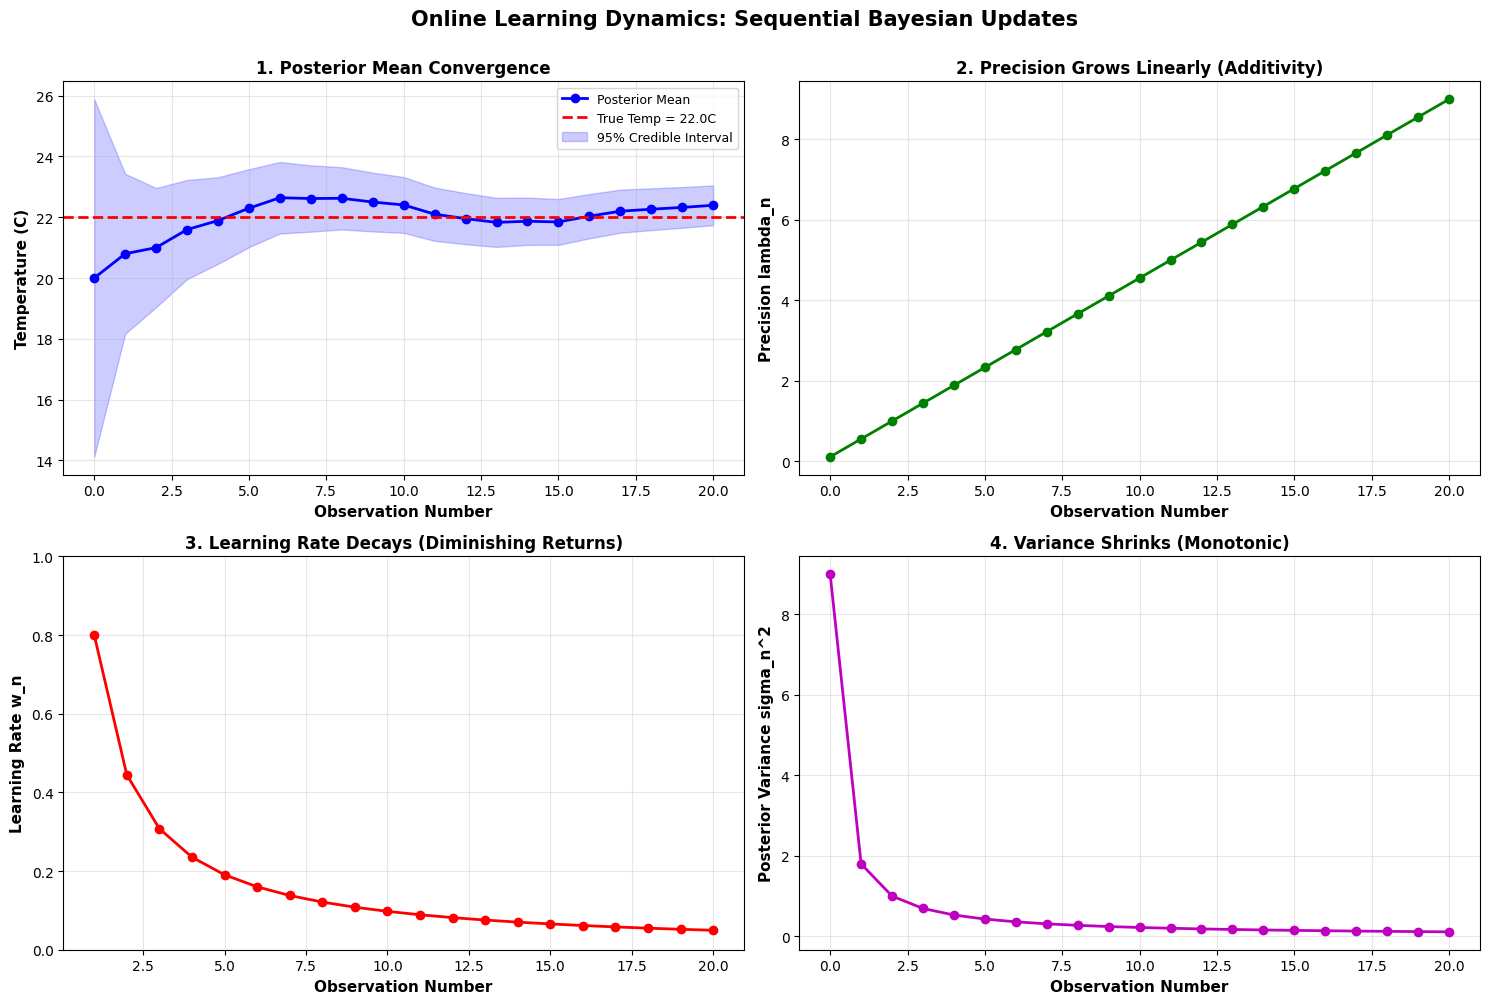

In [ ]:
# 4-panel visualization of online learning
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Posterior mean convergence
ax = axes[0, 0]
ax.plot(mu_history, 'b-o', markersize=6, linewidth=2, label='Posterior Mean')
ax.axhline(true_temp, color='red', linestyle='--', linewidth=2, label=f'True Temp = {true_temp}C')
ax.fill_between(range(len(mu_history)),
                 np.array(mu_history) - 1.96*np.array(sigma_history),
                 np.array(mu_history) + 1.96*np.array(sigma_history),
                 alpha=0.2, color='blue', label='95% Credible Interval')
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Temperature (C)', fontsize=11, fontweight='bold')
ax.set_title('1. Posterior Mean Convergence', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: Precision growth (LINEAR!)
ax = axes[0, 1]
ax.plot(lambda_history, 'g-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Precision lambda_n', fontsize=11, fontweight='bold')
ax.set_title('2. Precision Grows Linearly (Additivity)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel 3: Learning rate decay
ax = axes[1, 0]
ax.plot(range(1, n_readings+1), learning_rate_history, 'r-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Learning Rate w_n', fontsize=11, fontweight='bold')
ax.set_title('3. Learning Rate Decays (Diminishing Returns)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# Panel 4: Posterior variance shrinkage
ax = axes[1, 1]
ax.plot(np.array(sigma_history)**2, 'm-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Posterior Variance sigma_n^2', fontsize=11, fontweight='bold')
ax.set_title('4. Variance Shrinks (Monotonic)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Online Learning Dynamics: Sequential Bayesian Updates',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Q8. Extending Part 3: Non-stationary environment.
Modify the Part 3 temperature example so that the true temperature slowly drifts over time (e.g., true temp t = 22 + 0.1 * t).


Q8: NON-STATIONARY ONLINE LEARNING (Drifting True Temperature)

Initial prior: mu = 20.0C, sigma = 3.0C

After 20 sequential measurements:
  Final posterior (static-model): mu = 23.43C, sigma = 0.333C
  True temperature at last step:  T_20 = 24.00C

Learning rate progress:
  First observation: w_1  = 0.800
  Last observation:  w_20 = 0.049

-> With drift, the learner becomes overconfident (w_t decays), so it tends to lag behind changes.


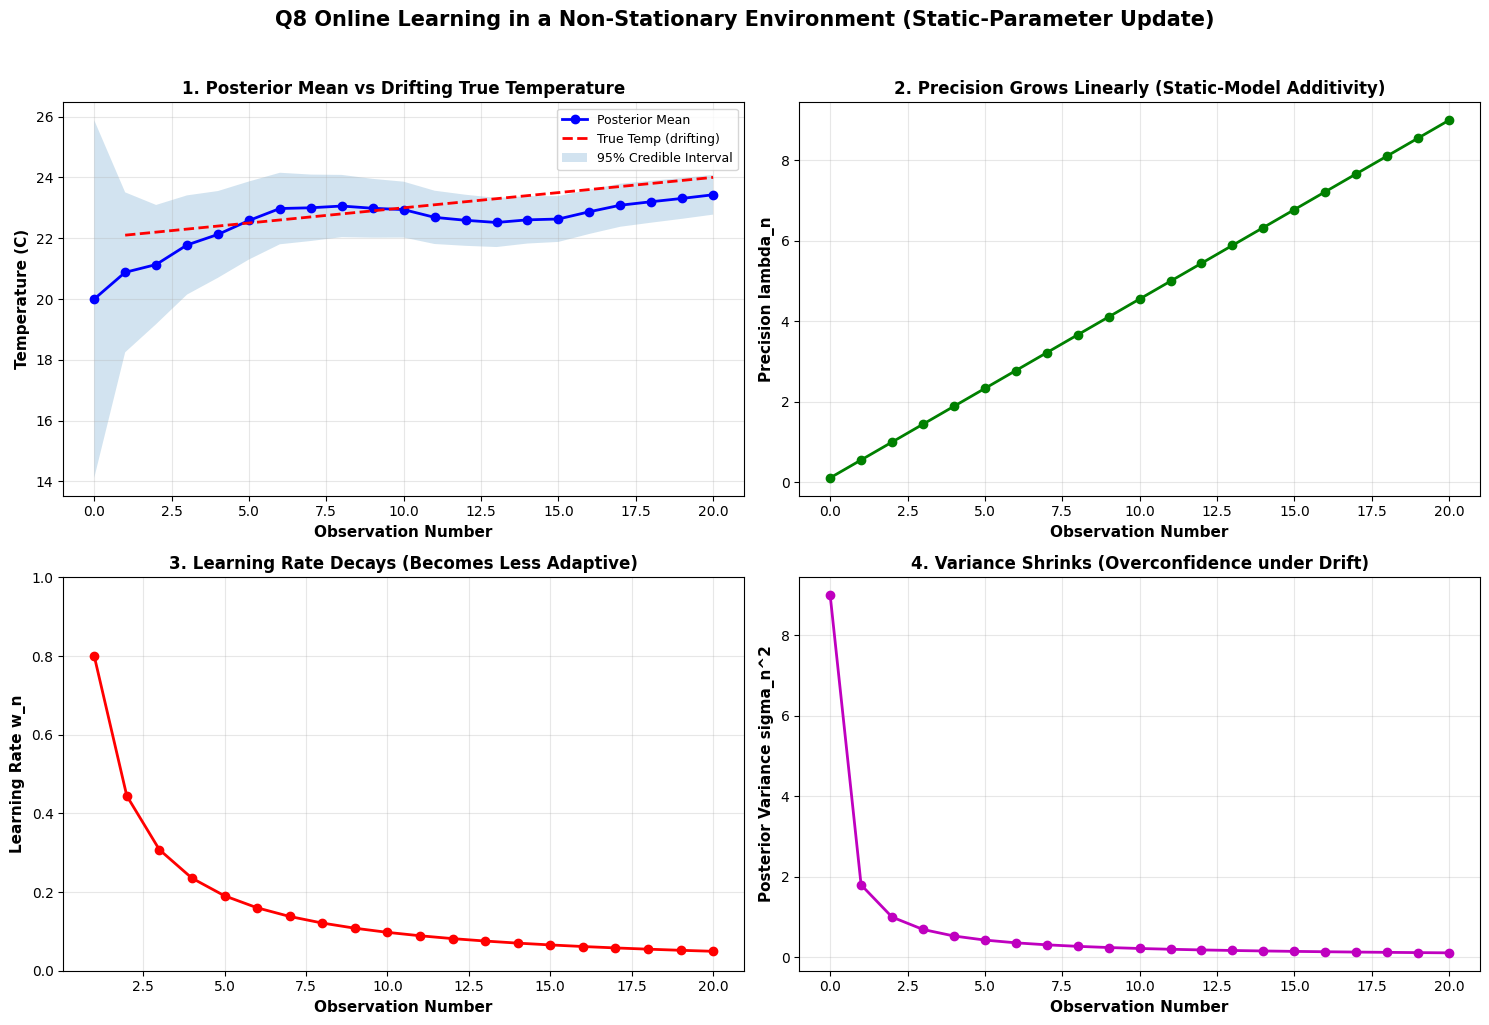

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sensor_noise = 1.5   # Known measurement error (std)
n_readings = 20

np.random.seed(456)

# true_temp_t = 22 + 0.1 * t
t_grid = np.arange(1, n_readings + 1)
true_temp_series = 22.0 + 0.1 * t_grid
temp_readings = np.random.normal(true_temp_series, sensor_noise, n_readings)

# Initial prior
mu_prior = 20.0
sigma_prior = 3.0
lambda_prior = 1 / sigma_prior**2

# Online update: store history
mu_history = [mu_prior]
sigma_history = [sigma_prior]
lambda_history = [lambda_prior]
learning_rate_history = []

mu_current = mu_prior
lambda_current = lambda_prior

# Online Bayesian update (UNCHANGED formulas)
for t, x_t in enumerate(temp_readings, 1):
    # Recursive update of precision
    lambda_new = lambda_current + 1 / sensor_noise**2

    # Learning rate
    w_t = (1 / sensor_noise**2) / lambda_new
    learning_rate_history.append(w_t)

    # Recursive update of mean
    mu_new = mu_current + w_t * (x_t - mu_current)

    # Store for visualization
    mu_history.append(mu_new)
    lambda_history.append(lambda_new)
    sigma_history.append(np.sqrt(1 / lambda_new))

    # Update for next iteration
    mu_current = mu_new
    lambda_current = lambda_new

print("\n" + "="*70)
print("Q8: NON-STATIONARY ONLINE LEARNING (Drifting True Temperature)")
print("="*70)
print(f"\nInitial prior: mu = {mu_prior:.1f}C, sigma = {sigma_prior:.1f}C")
print(f"\nAfter {n_readings} sequential measurements:")
print(f"  Final posterior (static-model): mu = {mu_history[-1]:.2f}C, sigma = {sigma_history[-1]:.3f}C")
print(f"  True temperature at last step:  T_20 = {true_temp_series[-1]:.2f}C")
print(f"\nLearning rate progress:")
print(f"  First observation: w_1  = {learning_rate_history[0]:.3f}")
print(f"  Last observation:  w_20 = {learning_rate_history[-1]:.3f}")
print(f"\n-> With drift, the learner becomes overconfident (w_t decays), so it tends to lag behind changes.")

# 4-panel visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
ax.plot(range(len(mu_history)), mu_history, 'b-o', markersize=6, linewidth=2, label='Posterior Mean')
ax.plot(t_grid, true_temp_series, 'r--', linewidth=2, label='True Temp (drifting)')

ax.fill_between(range(len(mu_history)),
                np.array(mu_history) - 1.96*np.array(sigma_history),
                np.array(mu_history) + 1.96*np.array(sigma_history),
                alpha=0.2, label='95% Credible Interval')

ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Temperature (C)', fontsize=11, fontweight='bold')
ax.set_title('1. Posterior Mean vs Drifting True Temperature', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2
ax = axes[0, 1]
ax.plot(lambda_history, 'g-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Precision lambda_n', fontsize=11, fontweight='bold')
ax.set_title('2. Precision Grows Linearly (Static-Model Additivity)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Panel 3
ax = axes[1, 0]
ax.plot(range(1, n_readings+1), learning_rate_history, 'r-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Learning Rate w_n', fontsize=11, fontweight='bold')
ax.set_title('3. Learning Rate Decays (Becomes Less Adaptive)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_ylim([0, 1])

# Panel 4
ax = axes[1, 1]
ax.plot(np.array(sigma_history)**2, 'm-o', markersize=6, linewidth=2)
ax.set_xlabel('Observation Number', fontsize=11, fontweight='bold')
ax.set_ylabel('Posterior Variance sigma_n^2', fontsize=11, fontweight='bold')
ax.set_title('4. Variance Shrinks (Overconfidence under Drift)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle('Q8 Online Learning in a Non-Stationary Environment (Static-Parameter Update)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Q12. Coding Problem – Simulation and Bayesian Updating



------------------------------------------------------------
N = 10
True rate θ₀ = 0.200
MLE θ̂ = 0.359
Posterior: Gamma(shape=14, rate=30.831)
Posterior mean = 0.454, posterior mode = 0.422
------------------------------------------------------------


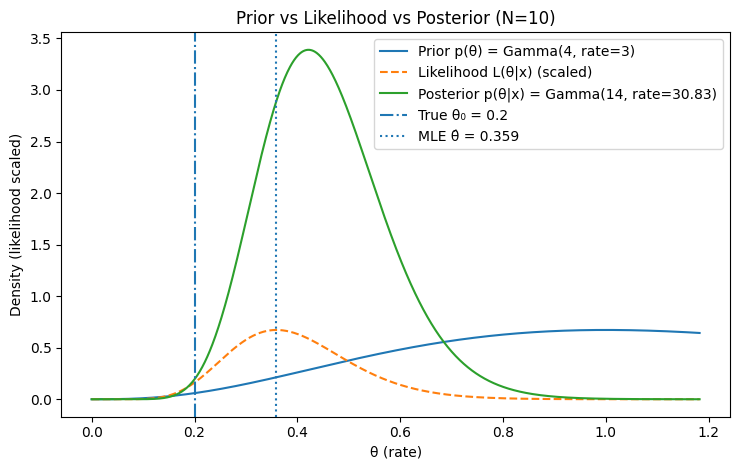


------------------------------------------------------------
N = 100
True rate θ₀ = 0.200
MLE θ̂ = 0.219
Posterior: Gamma(shape=104, rate=459.099)
Posterior mean = 0.227, posterior mode = 0.224
------------------------------------------------------------


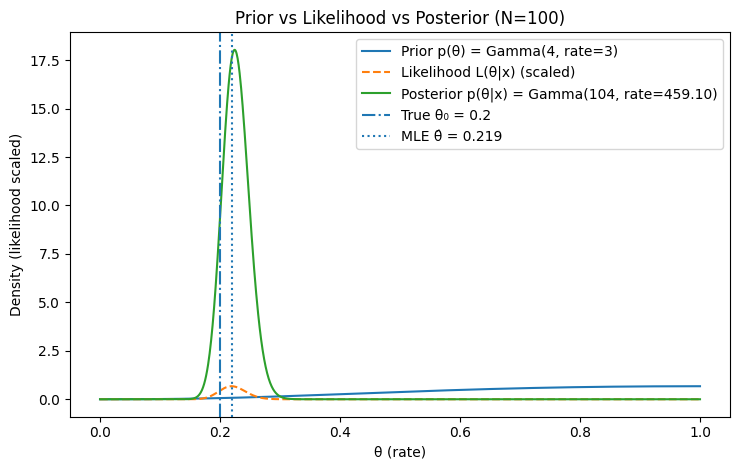

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Gamma Distribution
a0 = 4.0
b0 = 3.0
theta0 = 0.2
rng = np.random.default_rng(5218)
prior_dist = gamma(a=a0, scale=1.0 / b0)

def do_Q12_for_one_N(N: int):
    # (a) simulate data
    x = rng.exponential(scale=1.0 / theta0, size=N)
    S = x.sum()
    # (b) MLE
    theta_hat = N / S
    # (c) Posterior
    a_post = a0 + N
    b_post = b0 + S
    post_dist = gamma(a=a_post, scale=1.0 / b_post)

    # print
    print("\n" + "-"*60)
    print(f"N = {N}")
    print(f"True rate θ₀ = {theta0:.3f}")
    print(f"MLE θ̂ = {theta_hat:.3f}")
    print(f"Posterior: Gamma(shape={a_post:.0f}, rate={b_post:.3f})")
    print(f"Posterior mean = {a_post/b_post:.3f}, posterior mode = {(a_post-1)/b_post:.3f}" if a_post > 1 else
          f"Posterior mean = {a_post/b_post:.3f} (mode undefined for shape<=1)")
    print("-"*60)

    # plot
    post_mean = a_post / b_post
    post_sd = np.sqrt(a_post) / b_post
    theta_max = max(1.0, post_mean + 6 * post_sd, 2.0 * theta_hat)
    theta_grid = np.linspace(1e-6, theta_max, 1200)

    prior_pdf = prior_dist.pdf(theta_grid)
    post_pdf = post_dist.pdf(theta_grid)

    # likelihood
    like_unnorm = (theta_grid ** N) * np.exp(-S * theta_grid)
    like_scaled = like_unnorm / like_unnorm.max() * prior_pdf.max()

    # plot
    plt.figure(figsize=(7.5, 4.8))
    plt.plot(theta_grid, prior_pdf, label=f"Prior p(θ) = Gamma({a0:.0f}, rate={b0:.0f})")
    plt.plot(theta_grid, like_scaled, "--", label="Likelihood L(θ|x) (scaled)")
    plt.plot(theta_grid, post_pdf, label=f"Posterior p(θ|x) = Gamma({a_post:.0f}, rate={b_post:.2f})")
    plt.axvline(theta0, linestyle="-.", label=f"True θ₀ = {theta0}")
    plt.axvline(theta_hat, linestyle=":", label=f"MLE θ̂ = {theta_hat:.3f}")

    plt.title(f"Prior vs Likelihood vs Posterior (N={N})")
    plt.xlabel("θ (rate)")
    plt.ylabel("Density (likelihood scaled)")
    plt.legend()
    plt.tight_layout()
    plt.show()


for N in [10, 100]:
    do_Q12_for_one_N(N)
